# Reynolds Number Calculator
This notebook computes interstitial velocity and particle Reynolds number based on LBM simulation outputs.

In [1]:
# === User Inputs ===
Force = 250
porosity = 0.322
dx = 0.0003           # lattice spacing [m]
N_fluid = 2132450     # number of fluid nodes (from spreadsheet of threshold)
dp = 0.01             # particle diameter [m]
rho = 1.204           # fluid density [kg/m^3]
mu = 1.822e-5         # dynamic viscosity [kg/(m·s)]
integrated_vel = 2.69635e-05  # ∫|u| dV from ParaView

In [2]:
# === Calculations ===
cell_volume = dx**3
V_fluid = N_fluid * cell_volume
v_int = integrated_vel / V_fluid
Re_p = (rho * v_int * dp) / mu
V_total = V_fluid / porosity
v_s = porosity * v_int

print("\n--- Reynolds Number Calculation ---")
print(f"Force used: {Force} N")
print(f"Cell volume: {cell_volume:.3e} m^3")
print(f"Total fluid volume: {V_fluid:.3e} m^3")
print(f"Interstitial velocity v_int: {v_int:.4f} m/s")
print(f"Particle Reynolds number Re_p: {Re_p:.1f}")


--- Reynolds Number Calculation ---
Force used: 250 N
Cell volume: 2.700e-11 m^3
Total fluid volume: 5.758e-05 m^3
Interstitial velocity v_int: 0.4683 m/s
Particle Reynolds number Re_p: 309.5


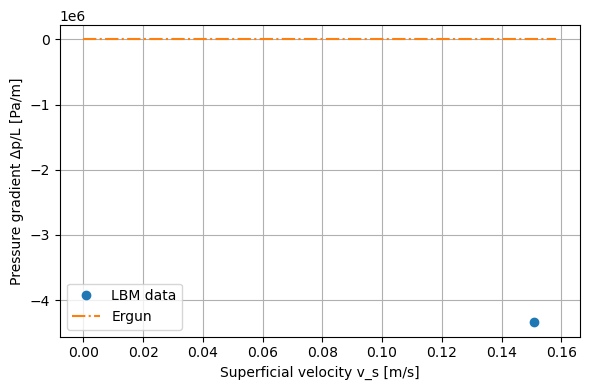

Data required for meaningful Ergun comparison:
- Multiple (Force, v_int) pairs across a range of forces
- Porosity (or V_total to compute porosity), particle diameter dp, fluid rho and mu
- (Optional) domain geometry / cross-sectional area if you want volumetric flow or conversion details


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# --- Inputs: supply arrays of forces and corresponding interstitial velocities ---
# If you only have a single measurement, the existing Force and v_int will be used as 1-element arrays.
forces = np.atleast_1d(Force)   # assumed total force [N] applied to the fluid volume
v_ints = np.atleast_1d(v_int)   # interstitial velocities [m/s] (from cell 2)

# broadcast if one is scalar
if forces.size != v_ints.size:
    if forces.size == 1:
        forces = np.full_like(v_ints, forces.item())
    elif v_ints.size == 1:
        v_ints = np.full_like(forces, v_ints.item())
    else:
        raise ValueError("forces and v_ints must have the same length or one must be scalar")

# --- Compute pressure gradient from body force ---
# Assuming Force is the total force on the fluid volume: body force per unit volume f = Force / V_fluid
# Then pressure gradient (Δp/L) = -f  (units Pa/m)
f_per_vol = forces / V_fluid
dpdx = -f_per_vol

# --- Compute superficial velocity ---
# Need porosity epsilon = V_fluid / V_total, or provide 'porosity' variable.
if 'V_total' in globals():
    porosity = V_fluid / V_total
elif 'porosity' in globals():
    porosity = porosity
else:
    raise ValueError(
        "Provide porosity (variable 'porosity') or total volume (variable 'V_total') to compute superficial velocity")

v_s = porosity * v_ints

# --- Darcy fit (linear region) to get permeability K ---
if v_s.size >= 2:
    # choose low-velocity points (<=30% of max) for Darcy regime, fallback to first two points
    if v_s.max() > 0:
        mask = v_s <= 0.3 * v_s.max()
    else:
        mask = np.ones_like(v_s, dtype=bool)
    if mask.sum() < 2:
        mask = np.arange(min(2, v_s.size))
    slope, intercept = np.polyfit(v_s[mask], dpdx[mask], 1)  # dpdx = slope * v_s + intercept
    K = mu / slope if slope != 0 else np.nan
else:
    slope = intercept = K = np.nan

# --- Ergun correlation ---
eps = porosity
ergun_a = (150.0 * (1 - eps)**2 / eps**3) * (mu / dp**2)
ergun_b = (1.75 * (1 - eps) / eps**3) * (rho / dp)
v_s_lin = np.linspace(0, v_s.max() * 1.05 if v_s.size else 1.0, 200)
dpdx_ergun = ergun_a * v_s_lin + ergun_b * v_s_lin**2

# --- Plot ---
plt.figure(figsize=(6,4))
plt.plot(v_s, dpdx, 'o', label='LBM data')
if not np.isnan(slope):
    plt.plot(v_s_lin, slope * v_s_lin + intercept, '--', label=f'Darcy fit (K={K:.2e} m^2)')
plt.plot(v_s_lin, dpdx_ergun, '-.', label='Ergun')
plt.xlabel('Superficial velocity v_s [m/s]')
plt.ylabel('Pressure gradient Δp/L [Pa/m]')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Summary of data required for Ergun comparison ---
print("Data required for meaningful Ergun comparison:")
print("- Multiple (Force, v_int) pairs across a range of forces")
print("- Porosity (or V_total to compute porosity), particle diameter dp, fluid rho and mu")
print("- (Optional) domain geometry / cross-sectional area if you want volumetric flow or conversion details")

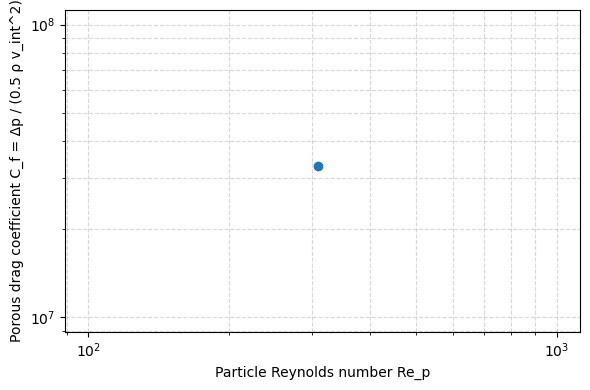

Re_p: [309.46515691]
C_f: [32887708.02957246]


In [4]:
# Porous drag coefficient vs particle Reynolds number
# C_f = Δp / (0.5 * rho * v_int^2)
v = np.asarray(v_ints, dtype=float)
Delta_p = -np.asarray(dpdx, dtype=float)   # use pressure drop (positive)
with np.errstate(divide='ignore', invalid='ignore'):
    C_f = Delta_p / (0.5 * rho * v**2)
    C_f = np.where(v == 0, np.nan, C_f)

Re_p_arr = rho * v * dp / mu

# plot (log-log)
plt.figure(figsize=(6,4))
idx = np.argsort(Re_p_arr)
plt.loglog(Re_p_arr[idx], C_f[idx], 'o-')
plt.xlabel("Particle Reynolds number Re_p")
plt.ylabel("Porous drag coefficient C_f = Δp / (0.5 ρ v_int^2)")
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Re_p:", Re_p_arr)
print("C_f:", C_f)